In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [67]:
df = pd.read_csv("gsales.csv", encoding='latin1', on_bad_lines='skip',sep=';')

In [68]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,Mar.77,Aðu.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.Aðu,Mar.58,Haz.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,Ara.88,Mar.79,Mar.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.Oca,Mar.28,Þub.96,33
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,Kas.27,Aðu.89,Eki.22,1,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0,0,0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0,0,0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0,0,0,0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0,0.01,0,0,0.01


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16572 non-null  object 
 3   Year          16301 non-null  float64
 4   Genre         16572 non-null  object 
 5   Publisher     16514 non-null  object 
 6   NA_Sales      16572 non-null  object 
 7   EU_Sales      16572 non-null  object 
 8   JP_Sales      16572 non-null  object 
 9   Other_Sales   16572 non-null  object 
 10  Global_Sales  16572 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 1.4+ MB


In [70]:
df = df.drop_duplicates(subset=['Rank'], keep='first')

In [71]:
df["Publisher"].value_counts()

Publisher
Electronic Arts                 1351
Activision                       975
Namco Bandai Games               932
Ubisoft                          921
Konami Digital Entertainment     832
                                ... 
Media Entertainment                1
New World Computing                1
Genterprise                        1
Rain Games                         1
UIG Entertainment                  1
Name: count, Length: 578, dtype: int64

In [72]:
df["Publisher"] = df["Publisher"].fillna("Unknown")

In [73]:
df["Year"] = pd.to_datetime(df["Year"], format = "%Y")

In [74]:
#Lazimi olan object tipindeki olan sutunlari numeric deyere cevirirk
cols_to_fix = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

df[cols_to_fix] = df[cols_to_fix].apply(pd.to_numeric, errors='coerce')

df[cols_to_fix].dtypes

NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Rank          16598 non-null  int64         
 1   Name          16598 non-null  object        
 2   Platform      16598 non-null  object        
 3   Year          16301 non-null  datetime64[ns]
 4   Genre         16598 non-null  object        
 5   Publisher     16598 non-null  object        
 6   NA_Sales      15688 non-null  float64       
 7   EU_Sales      16108 non-null  float64       
 8   JP_Sales      16336 non-null  float64       
 9   Other_Sales   16494 non-null  float64       
 10  Global_Sales  14563 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 1.4+ MB


In [76]:
df["Global_Sales"].sum()

np.float64(4030.9300000000003)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Rank          16598 non-null  int64         
 1   Name          16598 non-null  object        
 2   Platform      16598 non-null  object        
 3   Year          16301 non-null  datetime64[ns]
 4   Genre         16598 non-null  object        
 5   Publisher     16598 non-null  object        
 6   NA_Sales      16598 non-null  float64       
 7   EU_Sales      16598 non-null  float64       
 8   JP_Sales      16598 non-null  float64       
 9   Other_Sales   16598 non-null  float64       
 10  Global_Sales  16598 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 1.4+ MB


In [81]:
df["Genre"] = df["Genre"].fillna("Unknown2")

In [85]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16301,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006-05-25 19:42:29.659530112,0.155220,0.091520,0.049445,0.039391,0.276793
min,1.000000,1980-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007-01-01 00:00:00,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010-01-01 00:00:00,0.180000,0.091520,0.040000,0.039391,0.280000
max,16600.000000,2020-01-01 00:00:00,41.490000,29.020000,3.000000,1.000000,82.740000
std,4791.853933,NaN,0.495863,0.288343,0.126374,0.090808,1.187313


In [87]:
# bos olan satis sutunlarini ortalama ile doldurdum
satis_sutunlari = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

df[satis_sutunlari] = df[satis_sutunlari].fillna(df[satis_sutunlari].mean())

In [89]:
#Calculate total global sales by: Genre, Platform, Publisher (top 10 each)
categories = ['Genre', 'Platform', 'Publisher']

print("=== TOP 10 Qlobal Satış Analizi ===\n")

for cat in categories:

    top_10 = df.groupby(cat)['Global_Sales'].sum().sort_values(ascending=False).head(10)
    
    print(f"--- {cat} üzrə Top 10 ---")
    print(top_10)
    print("-" * 30, "\n")

=== TOP 10 Qlobal Satış Analizi ===

--- Genre üzrə Top 10 ---
Genre
Action          854.699289
Sports          788.690219
Role-Playing    458.047756
Shooter         456.873421
Misc            451.790772
Racing          373.108697
Platform        357.803793
Fighting        220.311522
Simulation      214.714915
Adventure       156.465287
Name: Global_Sales, dtype: float64
------------------------------ 

--- Platform üzrə Top 10 ---
Platform
PS2     615.626448
Wii     588.922469
DS      489.683788
X360    461.438325
PS3     406.160214
PS      332.358511
PSP     197.557176
GBA     193.508686
XB      180.330005
GB      123.679628
Name: Global_Sales, dtype: float64
------------------------------ 

--- Publisher üzrə Top 10 ---
Publisher
Nintendo                        821.155693
Electronic Arts                 469.835884
Activision                      365.772846
Ubisoft                         238.404351
Sony Computer Entertainment     235.818128
THQ                             212.587367

C:\Users\eemin\AppData\Local\Temp\ipykernel_19704\3336194647.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, ax=axes[i], palette='viridis')
C:\Users\eemin\AppData\Local\Temp\ipykernel_19704\3336194647.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, ax=axes[i], palette='viridis')
C:\Users\eemin\AppData\Local\Temp\ipykernel_19704\3336194647.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, ax=axes[i], palette='viridis')


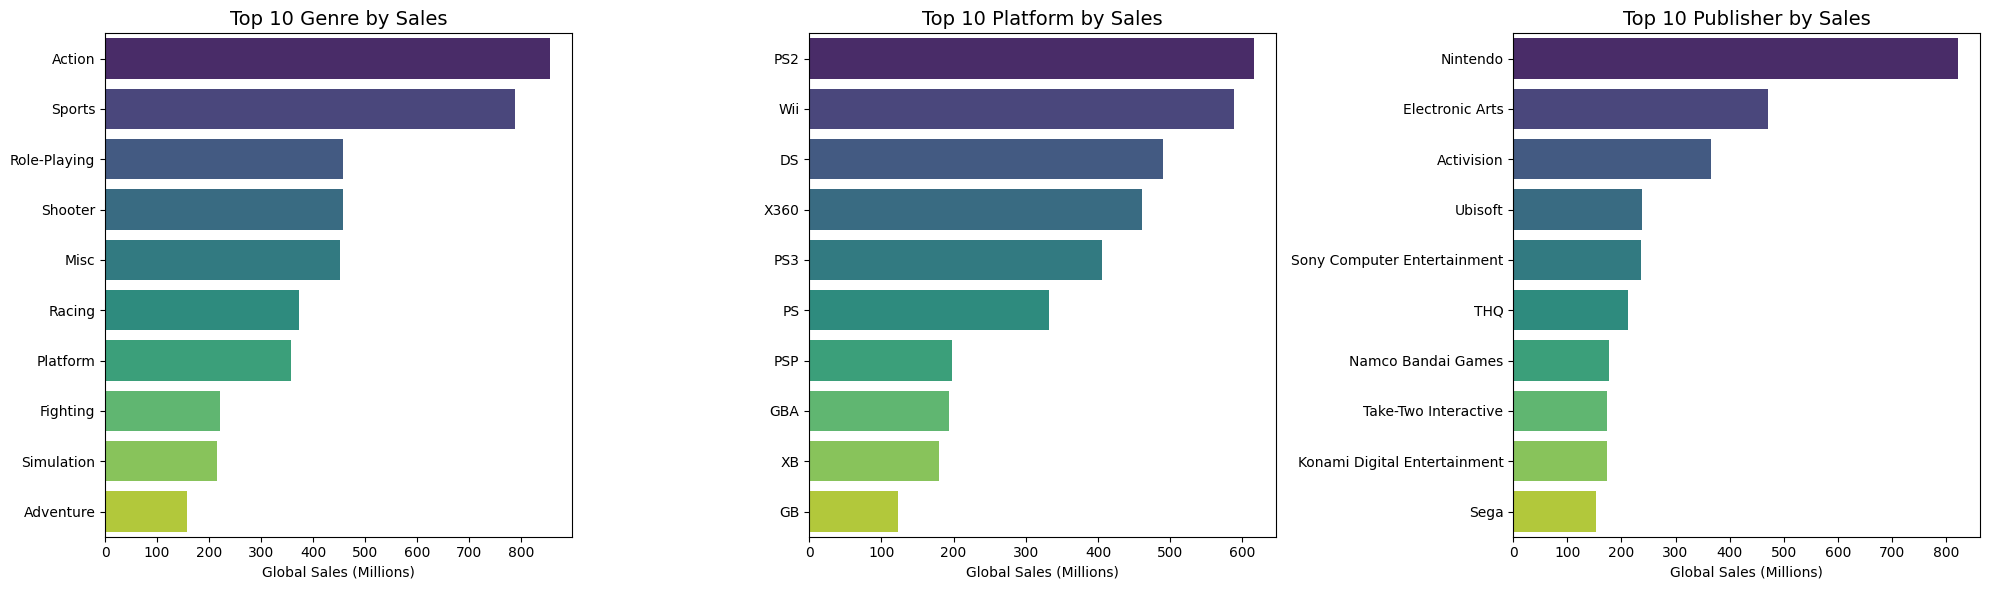

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
categories = ['Genre', 'Platform', 'Publisher']
colors = ['skyblue', 'salmon', 'lightgreen']

for i, cat in enumerate(categories):
    top_10 = df.groupby(cat)['Global_Sales'].sum().sort_values(ascending=False).head(10)
    
    sns.barplot(x=top_10.values, y=top_10.index, ax=axes[i], palette='viridis')
    
    axes[i].set_title(f'Top 10 {cat} by Sales', fontsize=14)
    axes[i].set_xlabel('Global Sales (Millions)')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

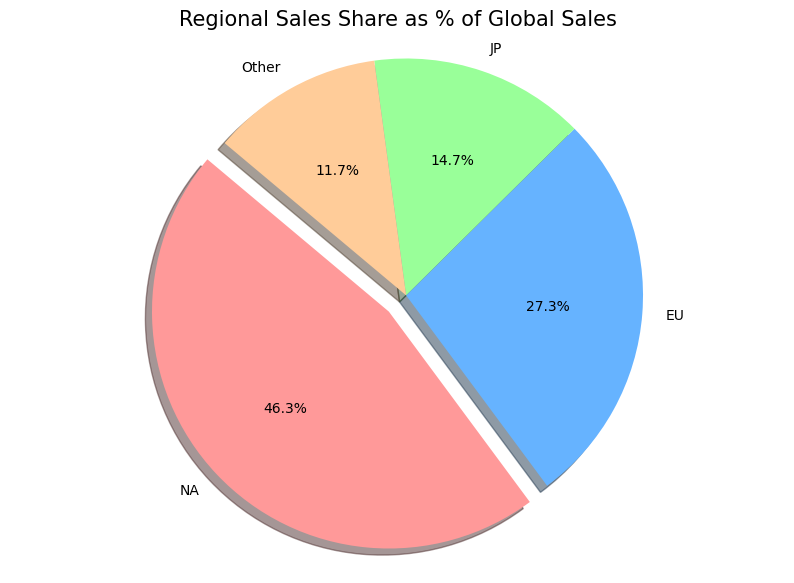

North America Payı: 46.25%
Europe Payı: 27.27%
Japan Payı: 14.73%


In [92]:
#Compare regional sales share: NA vs EU vs JP as % of Global_Sales
na_total = df['NA_Sales'].sum()
eu_total = df['EU_Sales'].sum()
jp_total = df['JP_Sales'].sum()
other_total = df['Other_Sales'].sum() 

labels = ['NA', 'EU', 'JP', 'Other']
sizes = [na_total, eu_total, jp_total, other_total]
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
explode = (0.1, 0, 0, 0) 

plt.figure(figsize=(10, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)

plt.title('Regional Sales Share as % of Global Sales', fontsize=15)
plt.axis('equal') 
plt.show()

print(f"North America Payı: {(na_total/sum(sizes))*100:.2f}%")
print(f"Europe Payı: {(eu_total/sum(sizes))*100:.2f}%")
print(f"Japan Payı: {(jp_total/sum(sizes))*100:.2f}%")

In [104]:
#Find which genre is most popular in each region (NA, EU, JP separately)
df.groupby("Genre")[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum().idxmax()

NA_Sales          Action
EU_Sales          Action
JP_Sales    Role-Playing
dtype: object

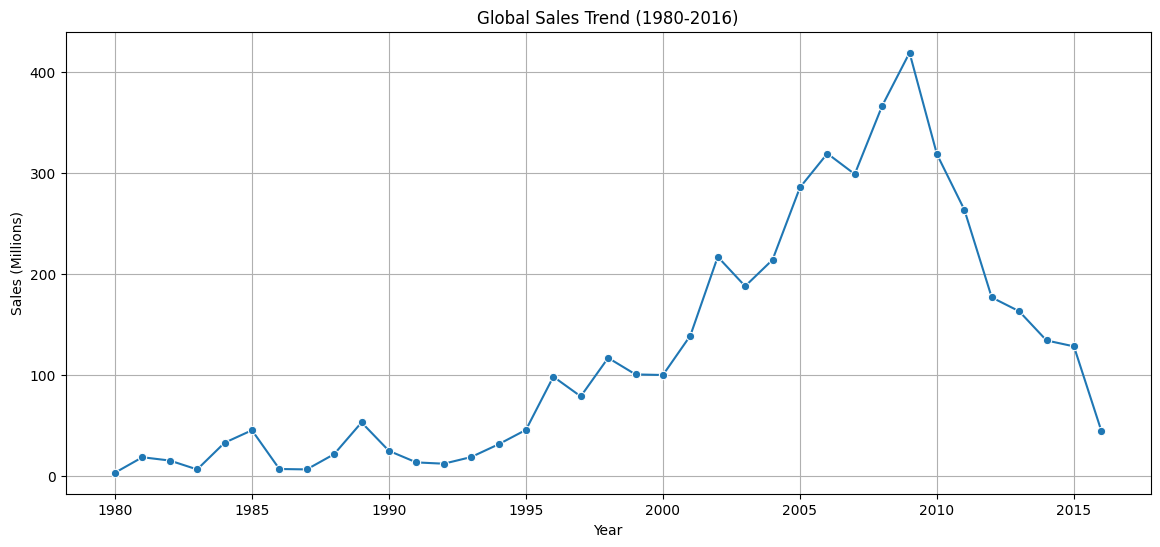

In [109]:
#Analyze yearly global sales trend from 1980 to 2016
df['Year'] = pd.to_datetime(df['Year'], errors='coerce')

df['Year_Only'] = df['Year'].dt.year

yearly_sales = df.groupby('Year_Only')['Global_Sales'].sum()
yearly_sales = yearly_sales.loc[1980:2016]


plt.figure(figsize=(14, 6))
sns.lineplot(x=yearly_sales.index, y=yearly_sales.values, marker='o')
plt.title('Global Sales Trend (1980-2016)')
plt.xlabel('Year')
plt.ylabel('Sales (Millions)')
plt.grid(True)
plt.show()

In [117]:
#Identify the top 10 best-selling games of all time with their platform and genre
top_10_games = df[['Name', 'Platform', 'Genre', 'Global_Sales']].sort_values(by='Global_Sales', ascending=False).head(10)

top_10_games.index = range(1, 11)

print("--- Bütün Zamanların Ən Çox Satan 10 Oyunu ---")
print(top_10_games)

--- Bütün Zamanların Ən Çox Satan 10 Oyunu ---
                         Name Platform         Genre  Global_Sales
1                  Wii Sports      Wii        Sports         82.74
2           Super Mario Bros.      NES      Platform         40.24
3              Mario Kart Wii      Wii        Racing         35.82
4           Wii Sports Resort      Wii        Sports         33.00
5    Pokemon Red/Pokemon Blue       GB  Role-Playing         31.37
6                      Tetris       GB        Puzzle         30.26
7                    Wii Play      Wii          Misc         29.02
8   New Super Mario Bros. Wii      Wii      Platform         28.62
9                   Duck Hunt      NES       Shooter         28.31
10                 Nintendogs       DS    Simulation         24.76


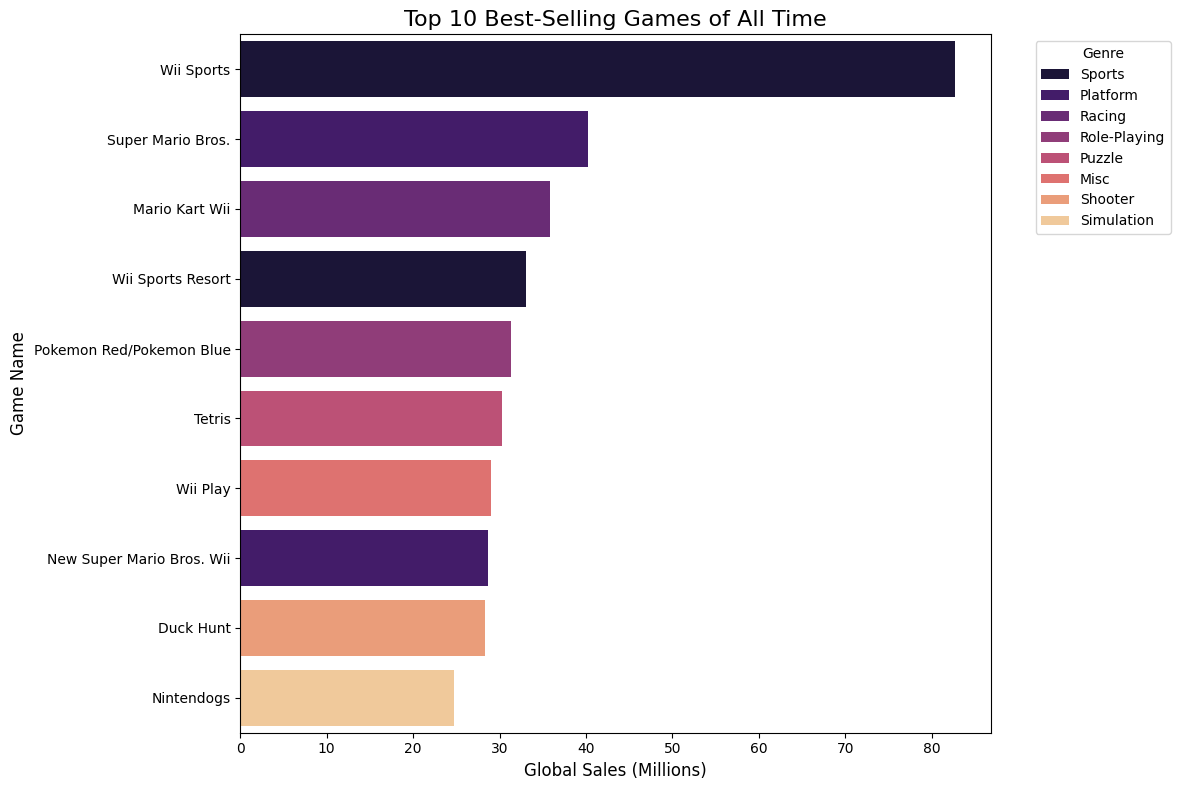

In [118]:
plt.figure(figsize=(12, 8))
sns.barplot(data=top_10_games, x='Global_Sales', y='Name', hue='Genre', palette='magma')

plt.title('Top 10 Best-Selling Games of All Time', fontsize=16)
plt.xlabel('Global Sales (Millions)', fontsize=12)
plt.ylabel('Game Name', fontsize=12)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Write 4 insights comparing regional market preferences

In [116]:
#1 Iller analizi etdikde gordumki 2008 ve ya 2009 uncu illerde satis 
#coxalibb bunun sebebini gormek ucun hemin illlerdeki en cox satilan 5 oyunu filterleyib gosterdm 
mask = (df['Year_Only'] == 2008) | (df['Year_Only'] == 2009)
peak_years = df[mask]

top_games_peak = peak_years[['Name', 'Platform', 'Year_Only', 'Global_Sales']].sort_values(by='Global_Sales', ascending=False).head(5)
top_games_peak

,Name,Platform,Year_Only,Global_Sales
2,Mario Kart Wii,Wii,2008.0,35.82
3,Wii Sports Resort,Wii,2009.0,33.00
8,New Super Mario Bros. Wii,Wii,2009.0,28.62
14,Wii Fit Plus,Wii,2009.0,22.00
36,Call of Duty: Modern Warfare 2,X360,2009.0,13.51


In [120]:
2# Pie chart ile etdiyimiz analizden melumdurki satislarin yarisi North America da olub bunun 
#esas sebeblerden biri "Action" ve "Shooter" janrindaki oyunlar daha telebatli olur
total_global = df['Global_Sales'].sum()
na_total = df['NA_Sales'].sum()
na_percentage = (na_total / total_global) * 100

print(f"Insight: North America qlobal oyun bazarinin {na_percentage:.1f}%-ni teskil edir.")

Insight: North America qlobal oyun bazarinin 56.1%-ni teskil edir.


<Axes: ylabel='Genre'>

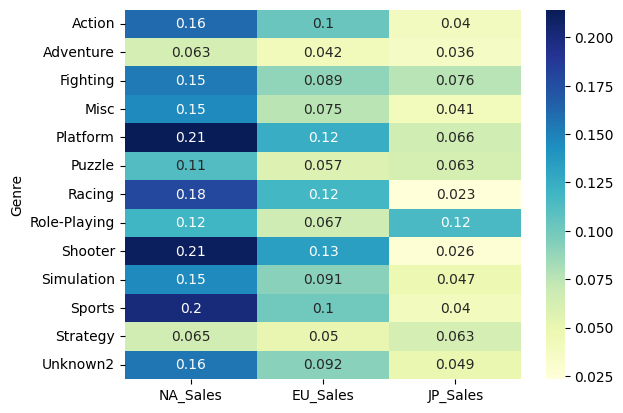

In [121]:
#3  Her regionun sevimli janri ferqlidir.

# "Yaponiya  bazarı Role-Playing (RPG) oyunlarını her seyden ustun tutur, halbuki Şimali Amerika
#ve Avropa  daha çox Action və Shooter oyunlarına pul xərcləyir."

genre_region = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].mean()
sns.heatmap(genre_region, annot=True, cmap='YlGnBu')